In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../'))

import numpy as np
import tensorflow as tf
import random, json

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

2026-05-14 22:54:43.387044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778799283.410246    1770 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778799283.417790    1770 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778799283.436227    1770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778799283.436244    1770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778799283.436246    1770 computation_placer.cc:177] computation placer alr

In [2]:
from src.pipeline.captioning_scratch import ImageCaptionerScratch
from src.pipeline.captioning_keras import ImageCaptionerKeras
from src.evaluation.metrics import compute_bleu4, timed_predict_from_features

VOCAB_PATH         = '../../data/captions/vocab.json'
TEST_CAPTIONS_PATH = '../../data/captions/test_captions.json'
TEST_FEATURES_PATH = '../../data/features/test_features.npy'

with open(TEST_CAPTIONS_PATH) as f:
    test_data = json.load(f)
test_image_names = list(test_data.keys())
test_references  = [test_data[name] for name in test_image_names]

test_features = np.load(TEST_FEATURES_PATH, allow_pickle=True).item()
if isinstance(test_features, dict):
    test_feat_matrix = np.stack([test_features[n] for n in test_image_names])
else:
    test_feat_matrix = test_features

In [3]:
BEST_WEIGHTS = '../../weights/rnn_lstm/rnn_preinject_L2_H512.h5'
BEST_TYPE    = 'rnn'

best_captioner = ImageCaptionerKeras(BEST_TYPE)
best_captioner.load_model('InceptionV3', BEST_WEIGHTS, VOCAB_PATH)

I0000 00:00:1778799294.432457    1770 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5447 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778799294.437736    1770 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13655 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
MAX_LEN_VARIANTS = [10, 15, 20, 25, 30]

ablation_results = {}

for max_len in MAX_LEN_VARIANTS:
    captions, total, avg = timed_predict_from_features(
        best_captioner, test_feat_matrix, max_len=max_len
    )
    bleu4 = compute_bleu4(test_references, captions)
    ablation_results[max_len] = {'bleu4': bleu4, 'avg_time': avg, 'captions': captions}
    print(f'max_len={max_len:2d}:  BLEU-4={bleu4:.4f}  avg_time={avg:.3f}s')

I0000 00:00:1778799297.585477    1816 service.cc:152] XLA service 0x30095730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778799297.585516    1816 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778799297.585520    1816 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778799297.675520    1816 cuda_dnn.cc:529] Loaded cuDNN version 91002


I0000 00:00:1778799298.311280    1816 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


max_len=10:  BLEU-4=0.0048  avg_time=0.617s


max_len=15:  BLEU-4=0.0048  avg_time=0.632s


max_len=20:  BLEU-4=0.0048  avg_time=0.631s


max_len=25:  BLEU-4=0.0048  avg_time=0.634s


max_len=30:  BLEU-4=0.0048  avg_time=0.639s


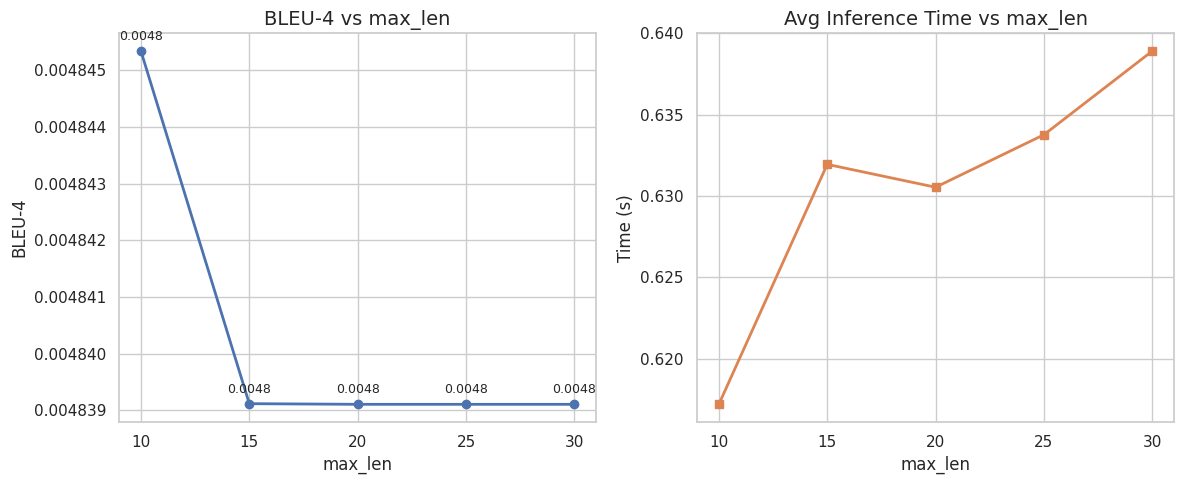

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns, os

sns.set_theme(style='whitegrid')
os.makedirs('../../results/plots', exist_ok=True)

lens   = sorted(ablation_results.keys())
bleu4s = [ablation_results[l]['bleu4']    for l in lens]
times  = [ablation_results[l]['avg_time'] for l in lens]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lens, bleu4s, marker='o', linewidth=2, color='#4C72B0')
axes[0].set_title('BLEU-4 vs max_len', fontsize=14)
axes[0].set_xlabel('max_len', fontsize=12)
axes[0].set_ylabel('BLEU-4', fontsize=12)
axes[0].set_xticks(lens)
for x, y in zip(lens, bleu4s):
    axes[0].annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

axes[1].plot(lens, times, marker='s', linewidth=2, color='#DD8452')
axes[1].set_title('Avg Inference Time vs max_len', fontsize=14)
axes[1].set_xlabel('max_len', fontsize=12)
axes[1].set_ylabel('Time (s)', fontsize=12)
axes[1].set_xticks(lens)

plt.tight_layout()
plt.savefig('../../results/plots/bleu4_vs_maxlen.png', dpi=150, bbox_inches='tight')
plt.show()

import json
with open('../../results/tables/caption_length_ablation.json', 'w') as f:
    json.dump({str(k): {'bleu4': v['bleu4'], 'avg_time': v['avg_time']} for k, v in ablation_results.items()}, f, indent=2)